# SSPictR 
Example notebook for generating SSPictR on CLEVR with masks - for more details see
[https://collaborative-ai.org/publications/penzkofer25_aic/](https://collaborative-ai.org/publications/penzkofer25_aic/) <br>

Uses sspspace library from https://github.com/ctn-waterloo/sspspace

In [1]:
import cv2
import numpy as np
import pandas as pd 

import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

import sspspace
import nengo_spa as spa

RGB_COLORS = plt.get_cmap('tab20').colors

## Load CLEVR with Masks
https://github.com/JohannesTheo/multi_object_datasets_torch

```bash
# install multi-objects-dataset
pip install tensorflow-cpu
pip install git+https://github.com/deepmind/multi_object_datasets.git@master
pip install git+https://github.com/JohannesTheo/multi_object_datasets_torch.git@main
```

In [2]:
from multi_object_datasets_torch import ClevrWithMasks

DATA_PATH = '/scratch/users/penzkofer/CLEVR/'

COLORS = ['red', 'cyan', 'green', 'blue', 'brown', 'gray', 'purple', 'yellow']
SHAPES = ['sphere', 'cylinder', 'cube']

CLASS_LST = ['BACKGROUND']
for color in COLORS: 
    for shape in SHAPES: 
        label = color.upper() + '_' + shape.upper()
        CLASS_LST.append(label)

training_data = ClevrWithMasks(DATA_PATH)
test_data     = ClevrWithMasks(DATA_PATH, split="Test")
print(len(training_data), len(test_data))

90000 5000


In [5]:
def plot_sample(img, segmap, save=False):
    cmap = matplotlib.colormaps.get_cmap('gist_ncar')
    
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(8,4))
    
    axs[0].imshow(img)
    axs[0].set_title('image')

    axs[1].imshow(segmap, cmap=cmap)
    axs[1].set_title('segmentation map')
    
    for ax in axs.ravel():
        ax.tick_params(axis='both', bottom=False, labelbottom=False, left=False, labelleft=False)
        
    plt.tight_layout()
    
    if save: 
        plt.savefig(f'segmentations_sample.png', dpi=300, bbox_inches='tight', facecolor='none')
    
    plt.show()
    
def mask_to_bbox(mask):
    y1, x1 = np.min(np.argwhere(mask), axis=0)
    y2, x2 = np.max(np.argwhere(mask), axis=0)
    bbox = [y1, x1, y2 - y1, x2 - x1]
    return bbox
    
def calc_iou(pred, gt): 
    """ calculates intersection-over-union (IoU) for pixel-based segmentation maps 
    iou = tp / (tp + fp + fn)
    see https://learnopencv.com/intersection-over-union-iou-in-object-detection-and-segmentation/#IoU-in-Image-Segmentattion
    """
    intersect = pred[pred == gt]
    opposite = pred[pred != gt]

    tn, tp = np.bincount(intersect.flatten(), minlength=2)
    fn, fp = np.bincount(opposite.flatten(), minlength=2)
    iou = tp / (tp + fp + fn)
    
    return iou, (tp, tn, fp, fn)

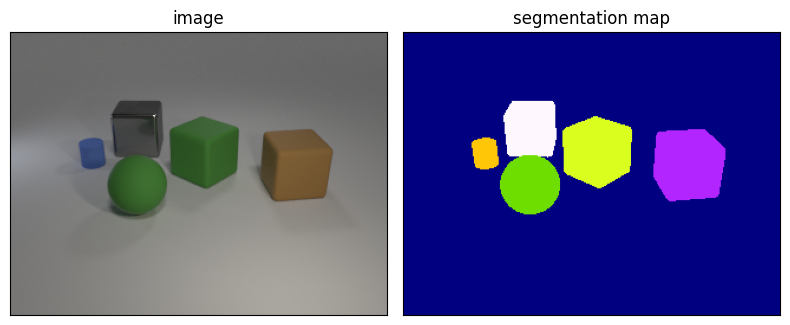

In [6]:
idx = 10

img = training_data[idx]['image'].squeeze() 
img = np.moveaxis(np.asarray(img), 0, 2)

mask = training_data[idx]['mask'].squeeze() 
segmap = np.zeros(mask.shape[1:])

all_bboxes = []
for i, m in enumerate(mask):
    
    if training_data[idx]['shape'][i] == 0 or training_data[idx]['color'][i] == 0: 
        continue
    
    label = COLORS[training_data[idx]['color'][i]-1].upper() + '_' +  SHAPES[training_data[idx]['shape'][i]-1].upper()
    label_idx = CLASS_LST.index(label)
    
    segmap[m == 255] = label_idx
    
    bbox = mask_to_bbox(m.cpu().detach().numpy())
    all_bboxes.append([*bbox, label_idx])

plot_sample(img, segmap)

## Generate SSPs on CLEVR with Masks

In [7]:
%%time
# Fix random seed
seed = 0
np.random.seed(seed)
RNG = np.random.default_rng(seed=seed)

# define ssp dimension and resolution of grid space 
SSP_DIM = 1945
RES_X, RES_Y = 320, 320
IMG_SIZE = (240, 320)

# define sampling parameters
PERCENTAGE = 10

# lengthscale hypeparameters -- need to be tuned 
GRID_LS = 12.5 
THRESHOLD = 0.4 

# Initialize SSP space
loc_space = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=18, n_scales=18, length_scale=GRID_LS)
assert SSP_DIM == loc_space.ssp_dim, f'{SSP_DIM} is not equal to {loc_space.ssp_dim}'

# Create nengo spa vocabulary for all COCO objects 
vocab = spa.Vocabulary(dimensions=SSP_DIM, pointer_gen=np.random.RandomState(0))
for obj in CLASS_LST:
    vocab.populate(obj)
    
# Generate xy coordinates -- this takes a while (can be excluded, only used for visualizations)
x_coords, y_coords = np.meshgrid(np.arange(0, RES_X), np.arange(0, RES_Y), indexing='ij')
coords = np.stack((x_coords.flatten(), y_coords.flatten()), axis=-1)
ssp_grid = loc_space.encode(coords)

print(f'Generated SSP grid: {ssp_grid.reshape((RES_X, RES_Y, -1)).shape}')

Generated SSP grid: (320, 320, 1945)
CPU times: user 16.7 s, sys: 12.5 s, total: 29.1 s
Wall time: 11.9 s


In [10]:
def encode_clevr_masks(data, ssp_grid, vocab, rng, percentage=10):
    
    all_masks = data['mask'].squeeze() 
    segmap = np.zeros(all_masks.shape[1:])

    all_objects = [COLORS[c-1].upper() + '_' + SHAPES[s-1].upper() for (c, s) in zip(data['color'], data['shape']) if not int(c) == 0 and not int(s) == 0]

    # Init memory
    memory = sspspace.SSP(np.zeros(vocab.dimensions))
    num_points = 0
    encoded_masks = {}
    for i, m in enumerate(all_masks):

        if data['color'][i] == 0 or data['shape'][i] == 0: 
            continue
        
        label = COLORS[data['color'][i]-1].upper() + '_' +  SHAPES[data['shape'][i]-1].upper()
        label_idx = CLASS_LST.index(label)

        # Get object mask 
        mask = (np.asarray(m) == 255)
        segmap[mask] = label_idx
        object_coords = np.argwhere(mask)
        encoded_masks[i] = mask

        # Calculate the number of points to sample based on the given percentage
        num_samples = int(len(object_coords)) * (percentage / 100.0)
        num_samples = max(num_samples, 1)  # Ensure at least one sample

        # Randomly sample points from the object's coordinates
        sampled_indices = rng.choice(len(object_coords), int(num_samples), replace=False)
        sampled_points = object_coords[sampled_indices]

        # Get new mask with sampled points
        mask = np.zeros((RES_X, RES_Y))
        mask[sampled_points[:,0], sampled_points[:,1]] = 1
        mask = mask.astype(bool)

        num_points += len(np.argwhere(mask.flatten()))

        # Get these xy coordinates from SSPs
        encoded_coords = ssp_grid[mask.flatten()]    
        encoded_label = vocab[label].v

        # Bind the encoded coordinates with the semantic pointer
        bound_vectors = encoded_coords.reshape(-1, SSP_DIM) * encoded_label[None, :]
        assert type(bound_vectors) == sspspace.ssp.SSP, 'Casting error'

        # normalize bound vector that represents one object and accumulate into memory
        bound_vector = sspspace.ssp.normalize(bound_vectors.sum(axis=0)[None, :])
        memory += bound_vector

    memory = sspspace.ssp.normalize(memory)
    return memory, encoded_masks, all_objects, num_points

def decode_clevr_masks(memory, all_objects, ssp_grid, vocab, img_size=(240, 320), visualize=False):
    all_ious = []
    all_simsmaps = []

    for i, label in enumerate(all_objects):

        # Retrieve the semantic pointer for the object and invert
        encoded_label = vocab[label].v 
        prompt = sspspace.SSP(encoded_label[None, :])
        ret_val = memory * ~prompt
        assert type(ret_val) == sspspace.ssp.SSP, 'Casting error'

        sims = np.dot(ret_val, ssp_grid.T)
        sims = np.array(sims).reshape(RES_X, RES_Y)
        sims = sims ** 2
        sims = sims / np.max(sims)
        all_simsmaps.append(sims)
        
        if visualize: 
            plt.imshow(sims)
            plt.axis('off')
            plt.show()

        # Calculate IoU of predicted and ground truth mask 
        iou, _ = calc_iou(sims[:img_size[0], :img_size[1]] > THRESHOLD, encoded_masks[i+1])
        all_ious.append(iou)
    
    return all_simsmaps, all_ious

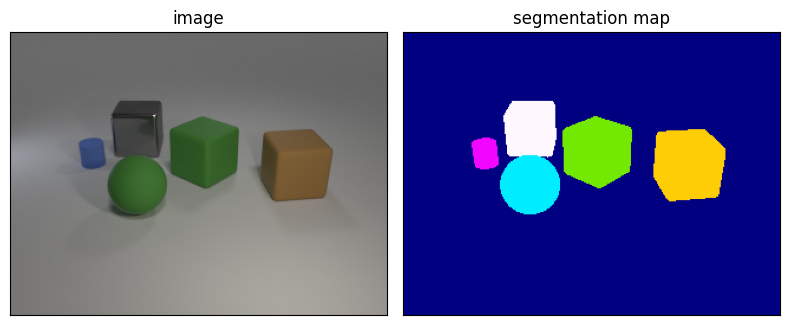

Average reconstruction IoU 82.12%


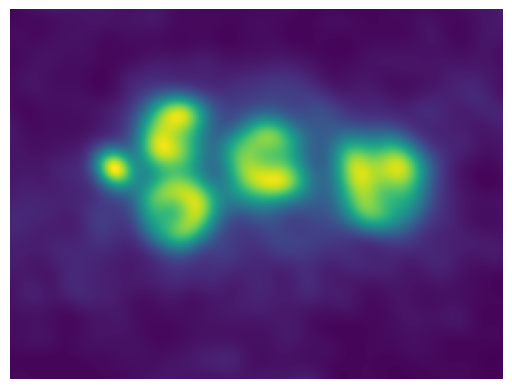

In [11]:
idx = 10

img = training_data[idx]['image'].squeeze() 
img = np.moveaxis(np.asarray(img), 0, 2)
segmap = np.zeros(training_data[idx]['mask'][0].shape)
for i, m in enumerate(training_data[idx]['mask']):
    segmap[m == 255] = i

plot_sample(img, np.asarray(segmap).squeeze())

memory, encoded_masks, all_objects, num_points = encode_clevr_masks(training_data[idx], ssp_grid, vocab, rng=RNG)
simsmaps, ious = decode_clevr_masks(memory, all_objects, ssp_grid, vocab, visualize=False)

print(f'Average reconstruction IoU {np.mean(ious):.2%}')

# plot all simsmaps overlayed 
plt.imshow(np.mean(np.array(simsmaps), axis=0))
plt.xlim(0, img.shape[1])
plt.ylim(img.shape[0], 0)
plt.axis('off')
plt.show()  

## Run Hyperparameter Search

In [14]:
%%time 

seed = 0
threshold = 0.4 # might want to optimize this as well (but only useful for decoding) 

final_results = []
for ls in [1, 4, 8, 12, 16, 20]:

    # Fix random seed
    np.random.seed(seed)
    RNG = np.random.default_rng(seed=seed)

    # Initialize SSP space
    loc_space = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=18, n_scales=18, length_scale=ls)
    assert SSP_DIM == loc_space.ssp_dim, f'{SSP_DIM} is not equal to {loc_space.ssp_dim}'

    # Create nengo spa vocabulary for all COCO objects 
    vocab = spa.Vocabulary(dimensions=SSP_DIM, pointer_gen=np.random.RandomState(0))
    for obj in CLASS_LST:
        vocab.populate(obj)

    # Generate xy coordinates -- this takes a while (can be excluded, only used for visualizations)
    x_coords, y_coords = np.meshgrid(np.arange(0, RES_X), np.arange(0, RES_Y), indexing='ij')
    coords = np.stack((x_coords.flatten(), y_coords.flatten()), axis=-1)
    ssp_grid = loc_space.encode(coords)

    print(f'Generated SSP grid: {ssp_grid.reshape((RES_X, RES_Y, -1)).shape}')

    avg_iou = 0
    results = []

    pbar = tqdm(range(100), desc=f'LS {ls}', unit='sample', ncols=115)
    for idx in pbar:
        memory, encoded_masks, all_objects, num_points = encode_clevr_masks(test_data[idx], ssp_grid, 
                                                                            vocab, rng=RNG)
        simsmaps, ious = decode_clevr_masks(memory, all_objects, ssp_grid, vocab, visualize=False)

        avg_iou += np.mean(ious)

        pbar.set_postfix(iou=f'{avg_iou/(idx + 1):.2%}')

        results.append({'ssp_dim': SSP_DIM, 'grid_ls': ls, 'threshold': threshold,
                        'num_objects': len(all_objects), 'encoded_labels': list(all_objects),
                        'encoded_points': num_points, 'ious': ious, 'avg_iou': np.mean(ious)})
    
    print(f'Average IoU: {avg_iou / len(pbar):.2%}')

    final_results.append({'ssp_dim': SSP_DIM, 'grid_ls': ls, 'threshold': threshold, 'avg_iou': np.mean(ious)})

Generated SSP grid: (320, 320, 1945)


LS 1: 100%|█████████████████████████████████████████████████████████| 10/10 [01:12<00:00,  7.24s/sample, iou=7.42%]


Average IoU: 7.42%
Generated SSP grid: (320, 320, 1945)


LS 4: 100%|████████████████████████████████████████████████████████| 10/10 [01:15<00:00,  7.58s/sample, iou=49.99%]


Average IoU: 49.99%
Generated SSP grid: (320, 320, 1945)


...

Average IoU: 62.46%
Generated SSP grid: (320, 320, 1945)


LS 16: 100%|███████████████████████████████████████████████████████| 10/10 [01:11<00:00,  7.20s/sample, iou=60.69%]


Average IoU: 60.69%
Generated SSP grid: (320, 320, 1945)


LS 20: 100%|███████████████████████████████████████████████████████| 10/10 [01:15<00:00,  7.55s/sample, iou=53.69%]

Average IoU: 53.69%
CPU times: user 16min 52s, sys: 40min 50s, total: 57min 43s
Wall time: 8min 33s


### Plot results

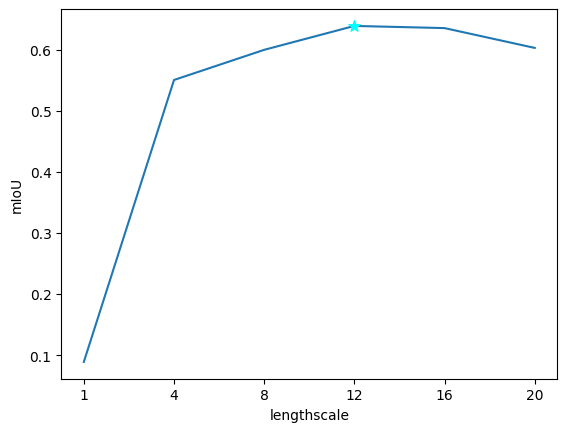

Best lengthscale is 12.0 with 63.87% mIoU


In [40]:
res_df = pd.DataFrame(final_results)
res_df.avg_iou.plot()
plt.xticks(np.arange(len(res_df)), res_df.grid_ls)
plt.xlabel('lengthscale')
plt.ylabel('mIoU')
plt.scatter(res_df.avg_iou.argmax(), res_df.avg_iou.max(), marker='*', s=70, color='cyan', zorder=3)
plt.show()
print(f'Best lengthscale is {res_df.iloc[res_df.avg_iou.argmax()].grid_ls} with {res_df.avg_iou.max():.2%} mIoU')